# Training CFP with a monotonicity penalty on screws images

This notebook is inspired by `Example_screws_preserve_root_morphological_target_training.ipynb` and keeps the same gray-level morphological target: foreground pixels keep the input gray level, while background pixels are set to the max-tree root level.

The validation here isolates the new spec-level monotonicity regularizer with two independent CFP layers:

- `layer_off`: one spec with `monotonicity_weight=0.0`;
- `layer_on`: one spec with `monotonicity_weight=MONOTONICITY_WEIGHT`.

The layers use the same data split, target, attributes, initialization, optimizer hyperparameters, and training batches, but they have separate parameters, caches, optimizers, and gradient clipping. This avoids the indirect coupling that happens when two specs are trained inside one layer with a shared optimizer step and global gradient clipping.

In [103]:
# If running outside a local checkout and mtlearn is not installed, uncomment:
# %pip install mtlearn

from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

# Prefer the local checkout when the notebook is launched from this repository.
# In Colab or another clean environment, uncomment the pip install above instead.
repo_root = Path.cwd()
for candidate in (repo_root, *repo_root.parents):
    if (candidate / "mtlearn" / "python" / "mtlearn").is_dir():
        local_python = candidate / "mtlearn" / "python"
        if str(local_python) not in sys.path:
            sys.path.insert(0, str(local_python))
        break

import mtlearn
from mtlearn import morphology

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE = 8
# Keep the default short enough for an example. Increase to 100+ for smoother curves.
NUM_EPOCHS = 200
LEARNING_RATE = 0.08
MONOTONICITY_WEIGHT = 100.25
PLOT_SAMPLES = 3
# Set these to small integers for a quick smoke run while editing the notebook.
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("mtlearn:", mtlearn.__file__)
print("device:", DEVICE)
print("monotonicity weight:", MONOTONICITY_WEIGHT)

mtlearn: /Volumes/SSD/GitHub/mtlearn/mtlearn/python/mtlearn/__init__.py
device: mps
monotonicity weight: 100.25


## Load data

The cache DataLoaders are deterministic and unshuffled because their job is only to build tree caches and normalization statistics. The actual training order is controlled later by the precomputed target DataLoader.

Inputs and masks are loaded in `[0, 1]`, but CFP tree construction quantizes inputs to `uint8`. The target defined below mirrors that quantization so the supervised signal is aligned with the tree actually used by the layer.

In [104]:
num_cols, num_rows = (int(1177 * 0.5), int(1324 * 0.499))
dir_name = str(mtlearn.data.ensure_dataset("screws_segmentation"))

dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    grayscale_in=True,
    invert_in=True,
    invert_target=True,
    numRows=num_rows,
    numCols=num_cols,
    scale_in=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
# Keep dataset tensors on CPU. The precomputed loaders move only mini-batches to DEVICE.
trainset = list(trainset)
testset = list(testset)
if MAX_TRAIN_SAMPLES is not None:
    trainset = trainset[:MAX_TRAIN_SAMPLES]
if MAX_TEST_SAMPLES is not None:
    testset = testset[:MAX_TEST_SAMPLES]

cache_trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)
cache_testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

num_pos = sum(int((y > 0.5).sum()) for _, y, _ in trainset)
num_pixels = sum(int(y.numel()) for _, y, _ in trainset)
print("resolution:", num_cols, "x", num_rows)
print("train/test:", len(trainset), len(testset))
print("foreground fraction:", num_pos / num_pixels)


screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
resolution: 588 x 660
train/test: 34 15
foreground fraction: 0.01975797894915542


## Morphological target

For a max-tree, the root level is the global minimum of the image used to build the tree. Because the CFP layer converts normalized inputs to `uint8` before tree construction, the target uses the same quantized scale and then maps back to `[0, 1]`.

The target keeps foreground gray values and flattens the background to the root level. This is compatible with `preserve_root=True`: the filter can suppress non-root residues while retaining the global baseline.

In [105]:
def input_as_tree_unit(x):
    """Match the quantized image scale used internally to build CFP trees."""
    x_u8 = (torch.clamp(x.detach(), 0.0, 1.0) * 255.0).to(torch.uint8)
    return x_u8.float().to(x.device) / 255.0


def morphological_target(x, mask):
    """Build the gray-level target once, outside the training loop."""
    x_tree = input_as_tree_unit(x)
    root = x_tree.flatten(2).amin(dim=2).view(x.shape[0], x.shape[1], 1, 1)
    foreground = mask > 0.5
    target = torch.where(foreground, x_tree, root)
    return target, root, foreground


def cfp_unit_output(layer, model_input):
    """CFP reconstructs uint8-level altitudes; divide by 255 for the target scale."""
    return layer(model_input) / 255.0


x0, y0, name0 = trainset[0]
target0, root0, mask0 = morphological_target(x0.unsqueeze(0), y0.unsqueeze(0))
print("sample:", name0)
print("input min/max:", float(x0.min()), float(x0.max()))
print("root level:", float(root0.squeeze()))
print("target min/max:", float(target0.min()), float(target0.max()))
print("sample foreground fraction:", float(mask0.float().mean()))

sample: 07_in.jpg
input min/max: 0.16470588743686676 0.9803921580314636
root level: 0.16470588743686676
target min/max: 0.16470588743686676 0.9803921580314636
sample foreground fraction: 0.019818078726530075


## Two independent CFP layers

Both layers preserve the root, so root attenuation is not part of this experiment. The only mathematical difference is the spec-level monotonicity weight.

The call to `init_identity_with_bias()` makes the initial parameters identical. That is important: the comparison should measure the effect of the extra loss term, not a different random initialization.

In [106]:
Type = morphology.AttributeType
attributes = (
    Type.AREA,
    Type.LENGTH_MAJOR_AXIS,
    Type.LENGTH_MINOR_AXIS,
    Type.INERTIA,
    Type.CIRCULARITY,
    Type.GRAY_HEIGHT,
    Type.RECTANGULARITY,
)


def make_layer(name, monotonicity_weight):
    return mtlearn.layers.ConnectedFilterPreprocessingLayer(
        in_channels=1,
        filter_specs=[
            {
                "name": name,
                "tree_type": morphology.TreeType.MAX_TREE,
                "attributes": attributes,
                "preserve_root": True,
                "monotonicity_weight": monotonicity_weight,
            }
        ],
        device=DEVICE,
        clamp=None,
    )


layer_off = make_layer("mono_off", 0.0)
layer_on = make_layer("mono_on", MONOTONICITY_WEIGHT)
layers = {"mono_off": layer_off, "mono_on": layer_on}
spec_names = list(layers)


def build_layer_caches(layer, label):
    t0 = time.time()
    train_cached = layer.build_dataloader_cached(cache_trainloader)
    test_cached = layer.build_dataloader_cached_fixed_stats(
        cache_testloader,
        index_offset=len(trainset),
    )
    print(f"{label} tree cache time seconds:", round(time.time() - t0, 3))
    return train_cached, test_cached


# Build the same indexed tree caches in each layer. The first cached loader is
# reused only to precompute the target dataset because its `(x, idx)` values are
# the same cache keys used by both layers.
trainloader_cached, testloader_cached = build_layer_caches(layer_off, "mono_off")
_ = build_layer_caches(layer_on, "mono_on")

for layer in layers.values():
    layer.init_identity_with_bias()

with torch.no_grad():
    initial_weight_diff = (layer_off._weights["mono_off"] - layer_on._weights["mono_on"]).abs().max()
    initial_bias_diff = (layer_off._biases["mono_off"] - layer_on._biases["mono_on"]).abs().max()
print("initial max weight diff:", float(initial_weight_diff))
print("initial max bias diff:", float(initial_bias_diff))
for name, layer in layers.items():
    spec = layer.get_config()["filter_specs"][0]
    print(name, "preserve_root=", spec["preserve_root"], "monotonicity_weight=", spec["monotonicity_weight"])

mono_off tree cache time seconds: 3.13
mono_on tree cache time seconds: 2.733
initial max weight diff: 0.0
initial max bias diff: 0.0
mono_off preserve_root= True monotonicity_weight= 0.0
mono_on preserve_root= True monotonicity_weight= 100.25


## Precompute the supervised target

The target, mask, and root level are materialized once in a `TensorDataset`. The training loop then uses the cached CFP trees and does not call `morphological_target(...)` repeatedly.

The cached indices are shared by the two layers because both layer caches were built from the same unshuffled dataset order and the same test `index_offset`.

In [107]:
def unpack_model_input(model_input):
    """Return image tensor and cache index from CFP cached-loader input."""
    if isinstance(model_input, (tuple, list)):
        return model_input[0], model_input[1]
    return model_input, None


@torch.no_grad()
def precompute_morphological_target_dataset(cached_loader, label):
    """Materialize the supervised target once for a cached CFP DataLoader."""
    xs, idxs, targets, masks, roots = [], [], [], [], []
    t0 = time.time()

    for model_input, mask in cached_loader:
        x, idx = unpack_model_input(model_input)
        target, root, _ = morphological_target(x, mask)

        xs.append(x.detach().cpu())
        idxs.append(idx.detach().cpu().long())
        targets.append(target.detach().cpu())
        masks.append(mask.detach().cpu())
        roots.append(root.detach().cpu())

    dataset = torch.utils.data.TensorDataset(
        torch.cat(xs, dim=0),
        torch.cat(idxs, dim=0),
        torch.cat(targets, dim=0),
        torch.cat(masks, dim=0),
        torch.cat(roots, dim=0),
    )
    print(f"{label} target cache: {len(dataset)} samples in {time.time() - t0:.3f}s")
    return dataset


train_target_dataset = precompute_morphological_target_dataset(trainloader_cached, "train")
test_target_dataset = precompute_morphological_target_dataset(testloader_cached, "test")

train_target_generator = torch.Generator(device="cpu")
train_target_generator.manual_seed(SEED)
train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_target_generator,
)
eval_train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
plot_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=min(PLOT_SAMPLES, len(test_target_dataset)),
    shuffle=False,
)

train target cache: 34 samples in 0.044s
test target cache: 15 samples in 0.014s


## Metrics

The reconstruction metrics compare each layer output with the same morphological target using the same ordinary MSE convention as `torch.nn.MSELoss`.

The monotonicity metrics inspect the learned node gates on cached max-trees:

```text
violation = relu(score_child - score_parent)
```

`violation_rate` is the fraction of parent-child edges whose violation is larger than a small numerical tolerance. `mono_mse` is the mean squared violation before multiplying by `monotonicity_weight`.

In [108]:
def split_precomputed_batch(batch):
    """Move a precomputed mini-batch to DEVICE and rebuild CFP cache input."""
    x, idx, target, mask, root = batch
    x = x.to(DEVICE)
    target = target.to(DEVICE)
    mask = mask.to(DEVICE)
    root = root.to(DEVICE)
    return (x, idx), x, target, mask, root


mse_loss = torch.nn.MSELoss()


@torch.no_grad()
def monotonicity_edge_sums(layer, model_input):
    """Return raw parent-child score-violation sums for one CFP layer."""
    x, idx = unpack_model_input(model_input)
    if idx is None:
        raise ValueError("monotonicity_edge_sums expects cached-loader input `(x, idx)`.")

    spec = layer.filter_specs[0]
    totals = {
        "edge_count": 0.0,
        "violation_count": 0.0,
        "violation_sum": 0.0,
        "violation_sq_sum": 0.0,
        "max_violation": 0.0,
    }

    for b in range(x.shape[0]):
        for c in range(x.shape[1]):
            base_key = f"{int(idx[b])}_{c}"
            layer._maybe_refresh_norm_for_key(base_key)
            info = layer._tree_info[base_key][spec.tree_key]
            norm_attrs = layer._norm_attrs[base_key][spec.tree_key]
            scores = layer._gate_scores(spec, info, norm_attrs)

            parent = info["parent"]
            node_ids = torch.arange(parent.numel(), device=parent.device)
            alive = info["tpost"] > info["tpre"]
            edge_mask = alive & alive[parent] & (parent != node_ids)
            if not bool(edge_mask.any().item()):
                continue

            violations = torch.relu(scores[edge_mask] - scores[parent[edge_mask]])
            totals["edge_count"] += float(violations.numel())
            totals["violation_count"] += float((violations > 1e-6).sum())
            totals["violation_sum"] += float(violations.sum())
            totals["violation_sq_sum"] += float(violations.pow(2).sum())
            totals["max_violation"] = max(totals["max_violation"], float(violations.max()))
    return totals


@torch.no_grad()
def evaluate(loader):
    for layer in layers.values():
        layer.eval()

    totals = {
        name: {
            "sse": 0.0,
            "abs_sum": 0.0,
            "pixel_count": 0.0,
            "fg_abs_sum": 0.0,
            "fg_count": 0.0,
            "bg_abs_sum": 0.0,
            "bg_count": 0.0,
            "edge_count": 0.0,
            "violation_count": 0.0,
            "violation_sum": 0.0,
            "violation_sq_sum": 0.0,
            "max_violation": 0.0,
        }
        for name in spec_names
    }

    for batch in loader:
        model_input, _, target, mask, _ = split_precomputed_batch(batch)
        foreground = mask > 0.5
        background = ~foreground

        for name, layer in layers.items():
            pred = cfp_unit_output(layer, model_input)
            err = pred - target
            abs_err = err.abs()
            row = totals[name]
            row["sse"] += float(err.pow(2).sum())
            row["abs_sum"] += float(abs_err.sum())
            row["pixel_count"] += float(abs_err.numel())
            row["fg_abs_sum"] += float(abs_err[foreground].sum())
            row["fg_count"] += float(foreground.sum())
            row["bg_abs_sum"] += float(abs_err[background].sum())
            row["bg_count"] += float(background.sum())

            edge_row = monotonicity_edge_sums(layer, model_input)
            for key in ("edge_count", "violation_count", "violation_sum", "violation_sq_sum"):
                row[key] += edge_row[key]
            row["max_violation"] = max(row["max_violation"], edge_row["max_violation"])

    metrics = {}
    for name, row in totals.items():
        metrics[name] = {
            "mse": row["sse"] / max(row["pixel_count"], 1.0),
            "mae": row["abs_sum"] / max(row["pixel_count"], 1.0),
            "fg_mae": row["fg_abs_sum"] / max(row["fg_count"], 1.0),
            "bg_mae": row["bg_abs_sum"] / max(row["bg_count"], 1.0),
            "mono_mean": row["violation_sum"] / max(row["edge_count"], 1.0),
            "mono_mse": row["violation_sq_sum"] / max(row["edge_count"], 1.0),
            "violation_rate": row["violation_count"] / max(row["edge_count"], 1.0),
            "max_violation": row["max_violation"],
        }
    return metrics


def print_metrics(epoch, metrics):
    print(f"epoch {epoch}")
    for name, row in metrics.items():
        print(
            f"  {name:8s} "
            f"mse={row['mse']:.6f} "
            f"mae={row['mae']:.6f} "
            f"bg_mae={row['bg_mae']:.6f} "
            f"mono_mse={row['mono_mse']:.6f} "
            f"viol_rate={row['violation_rate']:.3f} "
            f"max_viol={row['max_violation']:.3f}"
        )


history = []
init_metrics = evaluate(eval_train_target_loader)
history.append((0, init_metrics))
print_metrics("init", init_metrics)

epoch init
  mono_off mse=0.022092 mae=0.105123 bg_mae=0.107182 mono_mse=0.000000 viol_rate=0.000 max_viol=0.000
  mono_on  mse=0.022092 mae=0.105123 bg_mae=0.107182 mono_mse=0.000000 viol_rate=0.000 max_viol=0.000


## Training

Each layer has its own optimizer and its own gradient clipping. The unregularized layer minimizes only `torch.nn.MSELoss()`. The regularized layer minimizes the same MSE plus its own `monotonicity_penalty(...)`.

Two details matter for interpretation:

- `torch.nn.MSELoss()` uses mean reduction by default. Using `reduction="sum"` on these large images makes the reconstruction term dominate the monotonicity penalty.
- `init_identity_with_bias()` starts with nearly constant node scores. The initial monotonicity penalty is therefore zero, so the two layers can stay close until the reconstruction loss creates parent-child score violations.

In [109]:
optimizers = {
    name: torch.optim.Adam(layer.parameters(), lr=LEARNING_RATE, weight_decay=1e-7)
    for name, layer in layers.items()
}
report_epochs = {1, 2, 5, 10, NUM_EPOCHS}
report_epochs.update(epoch for epoch in range(20, NUM_EPOCHS + 1, 20))
objective_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    for layer in layers.values():
        layer.train()

    running = {
        name: {"fit_loss": 0.0, "mono_loss": 0.0, "count": 0}
        for name in spec_names
    }

    for batch in train_target_loader:
        model_input, _, target, _, _ = split_precomputed_batch(batch)
        batch_size = target.shape[0]

        for name, layer in layers.items():
            pred = cfp_unit_output(layer, model_input)
            fit_loss = mse_loss(pred, target)
            mono_loss = layer.monotonicity_penalty(model_input)
            loss = fit_loss + mono_loss

            optimizers[name].zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(layer.parameters(), max_norm=5.0)
            optimizers[name].step()

            running[name]["fit_loss"] += float(fit_loss.detach()) * batch_size
            running[name]["mono_loss"] += float(mono_loss.detach()) * batch_size
            running[name]["count"] += batch_size

    epoch_objective = {
        name: {
            "fit_loss": row["fit_loss"] / max(row["count"], 1),
            "mono_loss": row["mono_loss"] / max(row["count"], 1),
        }
        for name, row in running.items()
    }
    objective_history.append((epoch, epoch_objective))

    if epoch in report_epochs:
        print(f"objective epoch {epoch}")
        for name, row in epoch_objective.items():
            mono_over_fit = row["mono_loss"] / max(row["fit_loss"], 1e-12)
            print(
                f"  {name:8s} "
                f"fit={row['fit_loss']:.6f} "
                f"mono={row['mono_loss']:.6f} "
                f"mono/fit={mono_over_fit:.3f}"
            )
        metrics = evaluate(eval_train_target_loader)
        history.append((epoch, metrics))
        print_metrics(epoch, metrics)

print("test metrics")
print_metrics("test", evaluate(test_target_loader))

objective epoch 1
  mono_off fit=0.021749 mono=0.000000 mono/fit=0.000
  mono_on  fit=0.021943 mono=0.000048 mono/fit=0.002
epoch 1
  mono_off mse=0.020123 mae=0.099883 bg_mae=0.101385 mono_mse=0.000439 viol_rate=0.694 max_viol=0.039
  mono_on  mse=0.021742 mae=0.104330 bg_mae=0.106290 mono_mse=0.000000 viol_rate=0.335 max_viol=0.003
objective epoch 2
  mono_off fit=0.017716 mono=0.000000 mono/fit=0.000
  mono_on  fit=0.021516 mono=0.000111 mono/fit=0.005
epoch 2
  mono_off mse=0.010397 mae=0.065287 bg_mae=0.063434 mono_mse=0.035843 viol_rate=0.695 max_viol=0.351
  mono_on  mse=0.021158 mae=0.103027 bg_mae=0.104828 mono_mse=0.000001 viol_rate=0.242 max_viol=0.011
objective epoch 5
  mono_off fit=0.006132 mono=0.000000 mono/fit=0.000
  mono_on  fit=0.018182 mono=0.001523 mono/fit=0.084
epoch 5
  mono_off mse=0.006328 mae=0.013574 bg_mae=0.002660 mono_mse=0.019236 viol_rate=0.692 max_viol=0.295
  mono_on  mse=0.017628 mae=0.095198 bg_mae=0.095867 mono_mse=0.000014 viol_rate=0.152 max_vio

## Visual comparison

Both layers target the same gray-level image. The regularized layer should ideally retain a similar reconstruction while reducing parent-child score violations reported above.

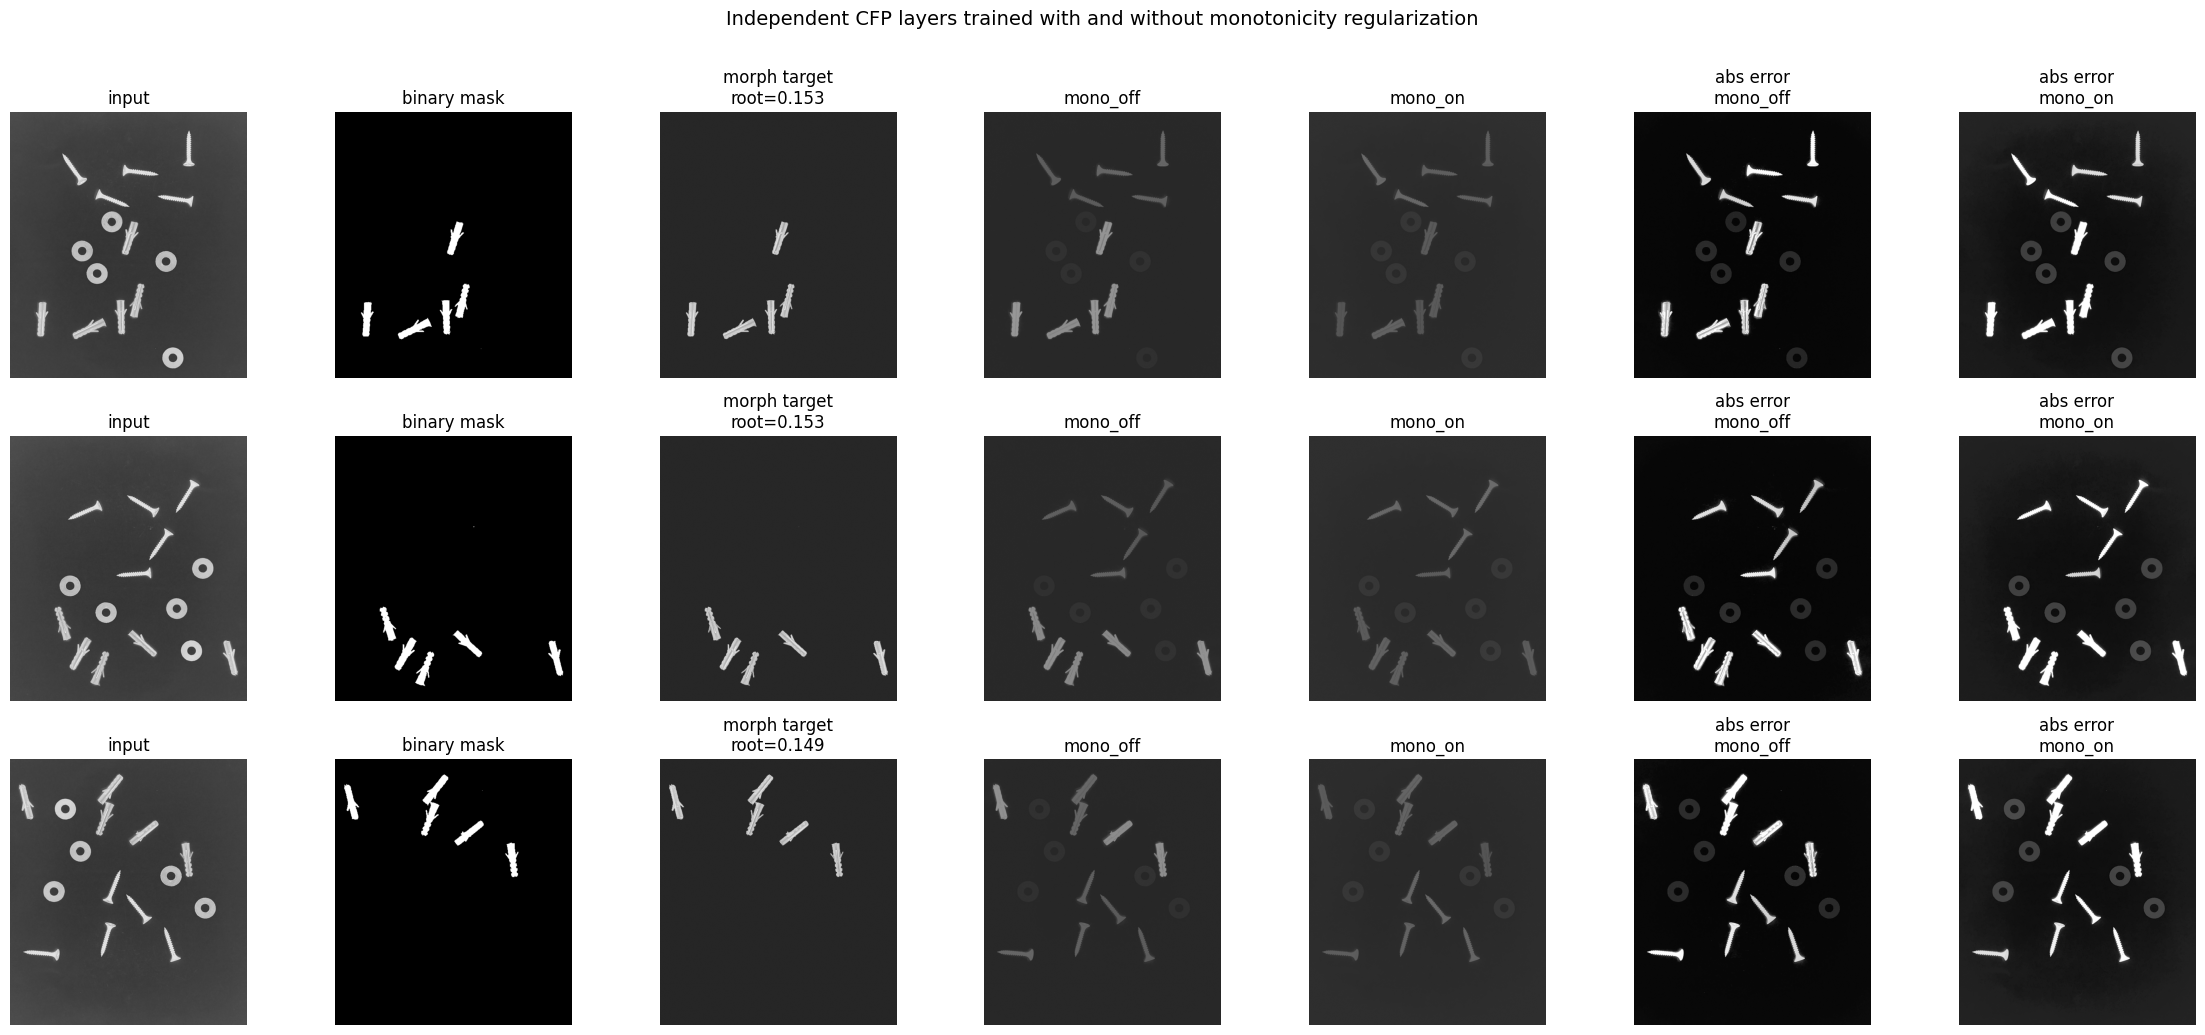

In [110]:
@torch.no_grad()
def plot_results(loader, title):
    for layer in layers.values():
        layer.eval()
    batch = next(iter(loader))
    model_input, x, target, mask, root = split_precomputed_batch(batch)
    preds = {name: cfp_unit_output(layer, model_input) for name, layer in layers.items()}

    n = min(PLOT_SAMPLES, x.shape[0])
    fig, axes = plt.subplots(n, 7, figsize=(23, 3.4 * n), squeeze=False)
    fig.suptitle(title, y=1.01, fontsize=14)

    for i in range(n):
        err_off = (preds["mono_off"][i, 0] - target[i, 0]).abs()
        err_on = (preds["mono_on"][i, 0] - target[i, 0]).abs()
        panels = [
            (x[i, 0], "input", 1.0),
            (mask[i, 0], "binary mask", 1.0),
            (target[i, 0], f"morph target\nroot={float(root[i, 0, 0, 0]):.3f}", 1.0),
            (preds["mono_off"][i, 0], "mono_off", 1.0),
            (preds["mono_on"][i, 0], "mono_on", 1.0),
            (err_off, "abs error\nmono_off", 0.25),
            (err_on, "abs error\nmono_on", 0.25),
        ]
        for ax, (image, panel_title, vmax) in zip(axes[i], panels):
            ax.imshow(image.detach().cpu(), cmap="gray", vmin=0.0, vmax=vmax)
            ax.set_title(panel_title)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_results(plot_target_loader, "Independent CFP layers trained with and without monotonicity regularization")

## Curves

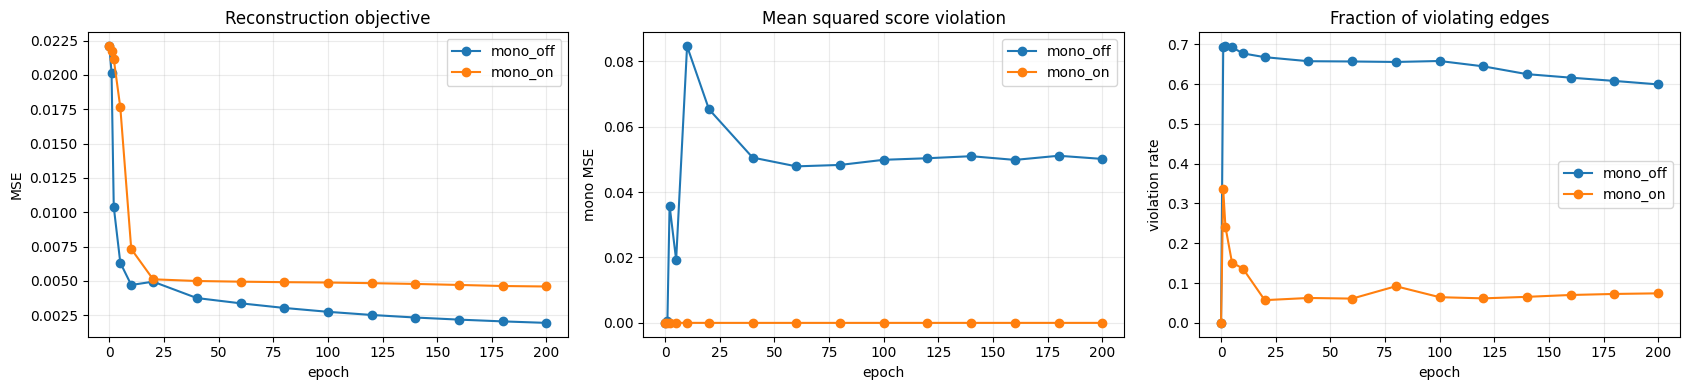

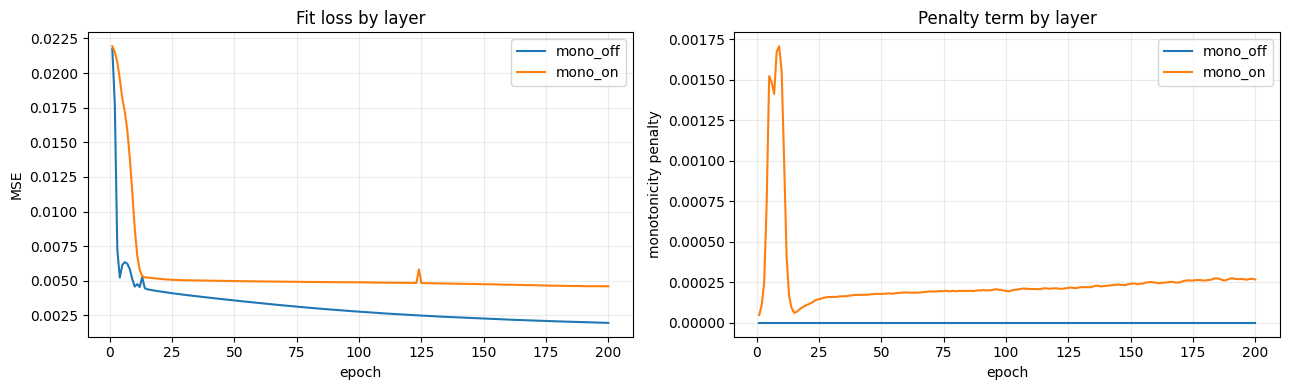

In [111]:
if history:
    epochs = [item[0] for item in history]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    for name in spec_names:
        axes[0].plot(
            epochs,
            [item[1][name]["mse"] for item in history],
            marker="o",
            label=name,
        )
        axes[1].plot(
            epochs,
            [item[1][name]["mono_mse"] for item in history],
            marker="o",
            label=name,
        )
        axes[2].plot(
            epochs,
            [item[1][name]["violation_rate"] for item in history],
            marker="o",
            label=name,
        )

    axes[0].set_title("Reconstruction objective")
    axes[0].set_ylabel("MSE")
    axes[1].set_title("Mean squared score violation")
    axes[1].set_ylabel("mono MSE")
    axes[2].set_title("Fraction of violating edges")
    axes[2].set_ylabel("violation rate")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

if objective_history:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = [row[0] for row in objective_history]
    for name in spec_names:
        axes[0].plot(epochs, [row[1][name]["fit_loss"] for row in objective_history], label=name)
        axes[1].plot(epochs, [row[1][name]["mono_loss"] for row in objective_history], label=name)
    axes[0].set_title("Fit loss by layer")
    axes[0].set_ylabel("MSE")
    axes[1].set_title("Penalty term by layer")
    axes[1].set_ylabel("monotonicity penalty")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

The main validation is not that `mono_on` always has the best target MSE. The regularizer adds a structural prior, so some reconstruction tradeoff is expected when the target asks for scores that conflict with parent-child monotonicity.

A useful outcome is:

- `mono_on` has lower `mono_mse`, lower `violation_rate`, or lower `max_violation` than `mono_off`;
- `mono_on` keeps target error in a comparable range;
- increasing `MONOTONICITY_WEIGHT` strengthens the structural constraint but can degrade reconstruction if the target is not compatible with a monotone criterion.

If the two layers remain very close, first inspect the printed `mono/fit` ratio. When it is near zero, the monotonicity term is too small relative to the MSE term to noticeably change the optimization. This can happen early in training because the identity initialization gives almost constant node scores, so the initial monotonicity penalty is exactly zero.

Because the two layers are independent, any difference is no longer caused by shared optimizer state or shared gradient clipping. It comes from the extra monotonicity term and the optimization trajectory it induces.

This is still a soft differentiable regularization, not a hard monotone projection. Violations can remain when the supervised task loss dominates the penalty.